# <center><font color='green'>Desafío 4 - Clasificación de calidad de ramen</font></center>

1. Realizar un análisis exhaustivo de calidad de datos para identificar y tratar posibles
valores faltantes, valores atípicos y errores en los datos. Garantizar que el conjunto
de datos esté limpio y preparado para su posterior procesamiento y entrenamiento
de los modelos.

In [31]:
# Importamos las bibliotecas necesarías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Creamos el dataframe usando 'pd.read_excel()'.
df= pd.read_excel('ramen-ratings.xlsx')

# Mostramos el dataframe creado.
df

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN
...,...,...,...,...,...,...,...
2575,5,Vifon,"Hu Tiu Nam Vang [""Phnom Penh"" style] Asian Sty...",Bowl,Vietnam,3.5,NaN
2576,4,Wai Wai,Oriental Style Instant Noodles,Pack,Thailand,1,NaN
2577,3,Wai Wai,Tom Yum Shrimp,Pack,Thailand,2,NaN
2578,2,Wai Wai,Tom Yum Chili Flavor,Pack,Thailand,2,NaN


In [32]:
# Vista general del dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review #  2580 non-null   int64 
 1   Brand     2580 non-null   object
 2   Variety   2580 non-null   object
 3   Style     2578 non-null   object
 4   Country   2580 non-null   object
 5   Stars     2580 non-null   object
 6   Top Ten   41 non-null     object
dtypes: int64(1), object(6)
memory usage: 141.2+ KB


In [33]:
# Calidad de los datos.
df.isnull().sum()

Review #       0
Brand          0
Variety        0
Style          2
Country        0
Stars          0
Top Ten     2539
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

#### Observaciones: 
- Se identificó que la variable Top Ten presenta un 98.4% de valores faltantes, por lo que vamos a eliminarla.
- La variable Style presenta solo 2 valores nulos, los cuales vamos a imputar utilizando la moda.
- La variable Stars no presenta valores faltantes, pero el tipo de daro no es correcto asi que vamos a cambiarlo.
- Finalmente, se eliminará la columna Review # por tratarse de un identificador sin valor predictivo.

In [35]:
# Eliminamos la columna 'Top Ten'.
df = df.drop(columns=['Top Ten'])

In [36]:
# Imputamos 'Style'.
df['Style'] = df['Style'].fillna(df['Style'].mode()[0])

In [37]:
# Cambiamos a 'numeric'.
df['Stars'] = pd.to_numeric(df['Stars'], errors='coerce')

In [38]:
df = df.drop(columns=['Review #'])

In [39]:
# Verificamos los cambios.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2580 non-null   object 
 1   Variety  2580 non-null   object 
 2   Style    2580 non-null   object 
 3   Country  2580 non-null   object 
 4   Stars    2577 non-null   float64
dtypes: float64(1), object(4)
memory usage: 100.9+ KB


In [40]:
# Eliminamos los 3 nulos que nos quedaron en la columna 'Stars'.
df = df.dropna(subset=['Stars'])

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2577 entries, 0 to 2579
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2577 non-null   object 
 1   Variety  2577 non-null   object 
 2   Style    2577 non-null   object 
 3   Country  2577 non-null   object 
 4   Stars    2577 non-null   float64
dtypes: float64(1), object(4)
memory usage: 120.8+ KB


In [42]:
# Análisis de outliers.
df.describe()

,Stars
count,2577.000000
mean,3.654676
std,1.015331
min,0.000000
25%,3.250000
50%,3.750000
75%,4.250000
max,5.000000


In [43]:
# Para las variables categóricas, vamosa ver si hay algún valor raro.
df['Country'].value_counts()

Country
Japan            352
USA              323
South Korea      307
Taiwan           224
Thailand         191
China            169
Malaysia         155
Hong Kong        137
Indonesia        126
Singapore        109
Vietnam          108
UK                69
Philippines       47
Canada            41
India             31
Germany           27
Mexico            25
Australia         22
Netherlands       15
Myanmar           14
Nepal             14
Pakistan           9
Hungary            9
Bangladesh         7
Colombia           6
Brazil             5
Cambodia           5
Poland             4
Fiji               4
Holland            4
Dubai              3
Sarawak            3
Sweden             3
Finland            3
Estonia            2
Ghana              2
Nigeria            1
United States      1
Name: count, dtype: int64

In [44]:
df['Style'].value_counts()

Style
Pack    1530
Bowl     481
Cup      450
Tray     108
Box        6
Can        1
Bar        1
Name: count, dtype: int64

#### Obervaciones: 
- La variable Stars fue analizada mediante estadísticas descriptivas, observándose que sus valores se encuentran dentro del rango esperado (0 a 5).
- En variables categóricas, se verificó la consistencia de las categorías sin detectar anomalías significativas.

2. Realizar el preprocesamiento de los datos, incluyendo la normalización o
estandarización de las características, codificación de variables categóricas y
división del conjunto de datos en conjuntos de entrenamiento y prueba.

In [45]:
# Primero vamos a definir la variable objetivo.
# Convertimos 'Stars' a binaria, 3.5 va a ser el umbral y vamos a crear la columna 'target' donde vamos a tener el resultado. 
# (También vamos a convertir a entero)
df['target'] = (df['Stars'] >= 3.5).astype(int)

In [46]:
# Borramos la columna, ya que no la vamos a usar.
df = df.drop(columns=['Stars'])

In [47]:
# Separamos variables.
X = df.drop(columns=['target'])
y = df['target']

In [48]:
# Dividimos el dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
# Codificamos las variables categóricas.
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Alineamos las columnas.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [50]:
# Escalamos.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

3. Dividir los datos en conjuntos de entrenamiento y prueba y entrenar dos modelos de
clasificación: uno utilizando Regresión Logística y otro utilizando Support Vector
Machine (SVM). Estos modelos servirán para determinar si un paquete de ramen es
"bueno" o "malo" en función de las características proporcionadas y realiza una
búsqueda de hiperparámetros.

In [51]:
# Regresión Logística.
log_reg = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

In [52]:
# SVM simple.
svm = SVC(C=1, kernel='linear', probability=True)
svm.fit(X_train, y_train)

best_svm = svm

#Durante el entrenamiento del modelo Support Vector Machine (SVM), se realizaron ajustes en la implementación debido a limitaciones computacionales.

4. Evaluar el rendimiento de ambos modelos utilizando métricas relevantes para
problemas de clasificación, como precisión, recall, F1-score y el área bajo la curva
ROC (AUC-ROC). A partir de esto, debes comparar y analizar los resultados obtenidos por cada modelo para determinar cuál es más adecuado para este problema
específico.

In [53]:
# Predicciones.
y_pred_lr = best_lr.predict(X_test)
y_pred_svm = best_svm.predict(X_test)

In [54]:
# Métricas básicas (precision, recall, F1).
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("SVM")
print(classification_report(y_test, y_pred_svm))

Logistic Regression
              precision    recall  f1-score   support

           0       0.71      0.19      0.30       152
           1       0.74      0.97      0.84       364

    accuracy                           0.74       516
   macro avg       0.72      0.58      0.57       516
weighted avg       0.73      0.74      0.68       516

SVM
              precision    recall  f1-score   support

           0       0.38      0.35      0.36       152
           1       0.74      0.76      0.75       364

    accuracy                           0.64       516
   macro avg       0.56      0.55      0.56       516
weighted avg       0.63      0.64      0.64       516



In [55]:
# AUC - ROC.
# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

# SVM (si no activaste probability=True, esto falla)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("AUC LR:", auc_lr)
print("AUC SVM:", auc_svm)

AUC LR: 0.6932385049161365
AUC SVM: 0.593515037593985


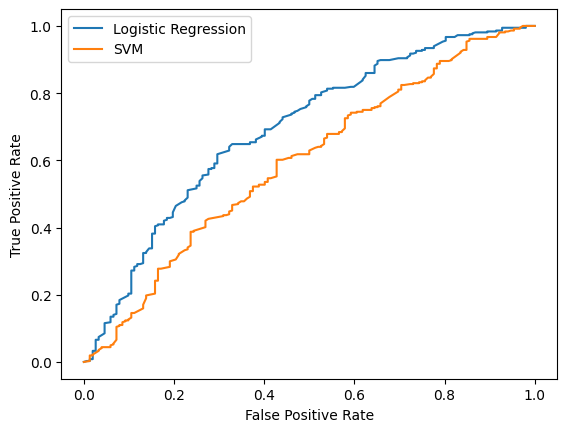

In [56]:
# Curva ROC.
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### Conclusiones:
La Regresión Logística presenta un mejor desempeño general en comparación con el modelo SVM, evidenciado por un mayor accuracy, F1-score y AUC-ROC. Además, muestra una alta capacidad para identificar correctamente los casos positivos (ramen “bueno”), con un recall de 0.97.
Por otro lado, el modelo SVM presenta un rendimiento inferior en todas las métricas evaluadas.
En consecuencia, la Regresión Logística resulta más adecuada para este problema.

#### Observaciones: 
Es importante destacar que el modelo SVM no fue optimizado completamente debido a limitaciones computacionales, lo que podría haber afectado su rendimiento. En particular, la ausencia de una búsqueda exhaustiva de hiperparámetros y el uso de un kernel lineal podrían haber limitado su capacidad de capturar relaciones complejas en los datos. Por lo tanto, los resultados obtenidos no necesariamente reflejan el máximo potencial del modelo.